In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import awkward as ak
import sys
import pandas as pd
import matplotlib
# Add the absolute path to the directory containing your module
sys.path.insert(0, '../scripts')

from plotting import *

In [2]:
#check number of cores and compile specter
num_cores = os.cpu_count()
print(f"Number of CPU cores: {num_cores}")

hpString="HS"
psString="PS"
hadString="HAD"
%load_ext autoreload
%autoreload 2

Number of CPU cores: 192


In [3]:
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy", points = "None"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weight = np.load(inputpath0+str_R+inputpath1)
        if type(points)!=str:
            weight = fix_weight_length(points, weight, weights_orig)
        weights.append(weight)
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
def fix_weight_length(points, weights, weights_orig):
    mask = np.all(points == 0, axis=(1, 2))
    if len(weights) != len(weights_orig):
        rw_weights = weights_orig.copy()
        print("Masking out zero values to fix different lengths: ", mask.shape, rw_weights.shape, weights.shape)
        rw_weights[~mask] = weights
        return rw_weights
    else:
        return weights

In [4]:
path = '/oscar/data/mleblan6/lhay/zjet_beta0p5/'

had_beta0p5_reweights = np.zeros((7, 100000))
had_beta0p5_radii = np.array([10,20,30,33,40,50,60])

for i in range(7):
    had_beta0p5_reweights[i] = np.load(f'{path}100k_had_emd_b0p5_reweight_{had_beta0p5_radii[i]}gev.npy')

for i in range(7):
    print(1 - len(had_beta0p5_reweights[i][had_beta0p5_reweights[i] < 0]) / 37581)

0.0
0.0028737926079668297
0.14576514728187118
0.2531864506000373
0.48293020409249354
0.7014714882520423
0.8229158351294537


In [5]:
with open("/oscar/data/mleblan6/rjain/jeppe/radii.txt") as f:
    code = f.read()
exec(code)
dataFrames = {}
weights_orig_z = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy")
jeppe_rw = np.load("/oscar/data/mleblan6/rjain/jeppe/jeppe_reweights.npy")
fracs = get_fracs(radii, jeppe_rw, weights_orig_z)
zjet_jeppe_df = pd.DataFrame({"radius": radii, "fraction": fracs, "weights": jeppe_rw.tolist()})
dataFrames["zjet_jeppe_df"] = {"process": "Zjets", "df": zjet_jeppe_df, "title": "Andersen et. al method"}

In [7]:
hp_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_XMD_v3.npy')
sho_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_XMD_v3.npy')
had_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_XMD_v3.npy')
hp_beta0p5_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_beta0p5_XMD.npy')
sho_beta0p5_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_beta0p5_XMD.npy')
had_beta0p5_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_beta0p5_XMD.npy')
hp_semd_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_semd_XMD.npy')
hp_betainf_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_betainf_XMD.npy')
sho_betainf_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_betainf_XMD.npy')
had_betainf_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_betainf_XMD.npy')
hp_p1semd_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_p1_semd_XMD.npy')
sho_p1semd_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_p1_semd_XMD.npy')
had_p1semd_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_p1_semd_XMD.npy')
hp_beta0_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_beta0_XMD.npy')
sho_beta0_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_beta0_XMD.npy')
had_beta0_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_beta0_XMD.npy')
had_beta2_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/had_beta2_XMD.npy')[:9]
sho_beta2_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/sho_beta2_XMD.npy')[:8]
hp_beta2_xmd_dist = np.load('/oscar/data/mleblan6/rjain/hundredK_XMD/hp_beta2_XMD.npy')

###ttbar xmds
ps_ttbar_xmd_dist = np.load('/oscar/data/mleblan6/lhay/xmd_outputs/ttbar_100k_xmd_ps.npy')
had_ttbar_xmd_dist = np.load('/oscar/data/mleblan6/lhay/xmd_outputs//ttbar_100k_xmd_had.npy')
hp_ttbar_xmd_dist = np.load('/oscar/data/mleblan6/lhay/xmd_outputs//ttbar_100k_xmd_hp.npy')
jeppe_xmd = np.load("/oscar/data/mleblan6/rjain/hundredK_XMD/jeppe_XMD.npy")
jeppe_xmd_ttbar = np.load("/oscar/data/mleblan6/rjain/hundredK_XMD/jeppe_XMD.npy")


In [8]:
##### Load jets
hp_points = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy")

# colors = tuple(tuple(c) for c in plt.cm.turbo(np.linspace(0.1, 1.0,  12)))
colors = [ "#ff1f2a", "#00a8fc", "#ff9d00", "#b374ff", "#64c704", "#0000ff", "#a60001", "#f65295", "#99dee1", "#9d02d7", "#ded800", "#007823" , "darkslategray" ]
colors2 = tuple(tuple(c) for c in plt.cm.turbo(np.linspace(0.1, 1.0, 10)))
markers = ["o", "p", "X", "h", "v", "^", "*", "s", "8", "d", "D", "P"]
pts = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy')[:,:,0]

#### define radii as when XMD's were run
max_hpht2 = np.max([pts[i].sum() for i in range(len(pts))])**2

pts = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/showered_points.npy')[:,:,0]
max_shoht2 = np.max([pts[i].sum() for i in range(len(pts))])**2

pts = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hadronization_points.npy')[:,:,0]
max_hadht2 = np.max([pts[i].sum() for i in range(len(pts))])**2

hp_semd_radii = np.logspace(1,np.log10(200),50)

betainf_radii = np.logspace(-4,-1,50)

beta0_radii = np.logspace(1.5,3,50)

hp_p1semd_radii = np.logspace(-5,-2,50) * max_hpht2
sho_p1semd_radii = np.logspace(-4,-2,50) * max_shoht2
had_p1semd_radii = np.logspace(-4,-2,50) * max_hadht2


weight = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')

#### load original weights for ttbar, z+jet
N=10000
weights_orig_10k = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')[N:2*N]

#### making the beta=1 hard process dataframe
radii_hp = [5, 7, 9, 9.2, 9.5, 10, 12, 12.5, 12.9, 13.1, 15, 18, 20, 25]
zjet_hp_df = make_df(radii_hp, weight, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_","gev_bigR.npy", points=hp_points)
dataFrames["zjet_hp_df"] = {"process": "Zjets", "df": zjet_hp_df, "xmd":hp_xmd_dist, "title": r"$\beta=1$ %s "%hpString, "color": colors[0], "marker": markers[0]}
#### print the available fractions
#print(zjet_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = zjet_hp_df["fraction"]


#### showered
radii_ps_100k =  [5, 9, 10, 12.5, 12.6, 15, 17.2, 20, 25]
zjet_ps_df = make_df(radii_ps_100k, weight, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_","gev_bigR.npy")
dataFrames["zjet_ps_df"] = {"process": "Zjets", "df": zjet_ps_df, "xmd":sho_xmd_dist, "title": r"$\beta=1$ %s "%psString, "color": colors[1], "marker": markers[0]}

#### hadronization 
# radii_had_100k = [5, 10, 13, 15, 17.2, 20, 25 ]
radii_had_100k = [5, 10, 13, 15, 17.2, 20, 25]
zjet_had_df = make_df(radii_had_100k, weight, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_","gev_bigR.npy")
# zjet_had_df = make_df(radii_had_100k, weight, "/oscar/data/mleblan6/lhay/reweighted_files/zjet_100k_had/100k_had_emd_reweight_","gev_bigR.npy")
dataFrames["zjet_had_df"] = {"process": "Zjets", "df": zjet_had_df, "xmd":had_xmd_dist, "title": r"$\beta=1$ %s "%hadString, "color": colors[2], "marker": markers[0]}


###### Camille hard process SEMD RW's
hp_semd_reweights = np.load('/oscar/data/mleblan6/rjain/semd_reweight/hardprocess_reweights.npy')
fracs = get_fracs(np.logspace(1,np.log10(200),50), hp_semd_reweights, weight)
zjet_SEMD_p2_hp_df = pd.DataFrame({"radius": np.logspace(1,np.log10(200),50), "fraction": fracs, "weights": hp_semd_reweights.tolist()})
dataFrames["zjet_SEMD_cm"] = {"process": "Zjets", "df": zjet_SEMD_p2_hp_df,"xmd":hp_semd_xmd_dist, "title": "SEMD p=2 %s"%hpString, "color": colors[3], "marker": markers[1]}

#### Jeppe RW
with open("/oscar/data/mleblan6/rjain/jeppe/radii.txt") as f:
    code = f.read()
exec(code)
jeppe_rw = np.load("/oscar/data/mleblan6/rjain/jeppe/jeppe_reweights.npy")
fracs = get_fracs(radii, jeppe_rw, weight)
zjet_jeppe_df = pd.DataFrame({"radius": radii, "fraction": fracs, "weights": jeppe_rw.tolist()})
dataFrames["zjet_jeppe_df"] = {"process": "Zjets", "df": zjet_jeppe_df, "xmd":jeppe_xmd,"title": "Andersen $et$ $al.$", "color": colors[4], "marker": markers[2]}

##### Rishabh SEMD RW's w/ p=1
radii_hp = np.logspace(-5,-2,50)
hp_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hardprocess_reweights.npy")
hp_rw = np.array([fix_weight_length(hp_points, rw, weight) for rw in hp_rw])
fracs = get_fracs(radii_hp, hp_rw, weight)
zjet_SEMD_hp_df = pd.DataFrame({"radius": radii_hp, "fraction": fracs, "weights": hp_rw.tolist()})
dataFrames["zjet_SEMD_hp_df"] = {"process": "Zjets", "df": zjet_SEMD_hp_df, "xmd":hp_p1semd_xmd_dist, "title": "SEMD p=1 %s"%hpString, "marker": markers[3], "color":colors2[0]}

    
radii_ps =  np.logspace(-4,-2,50)
ps_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/showered_reweights.npy")
fracs = get_fracs(radii_ps, ps_rw, weight)
zjet_SEMD_ps_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": ps_rw.tolist()})
dataFrames["zjet_SEMD_ps_df"] = {"process": "Zjets", "df": zjet_SEMD_ps_df, "xmd":sho_p1semd_xmd_dist, "title": "SEMD p=1 %s"%psString, "marker": markers[3], "color": colors[8]}

had_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hadronization_reweights.npy")
fracs = get_fracs(radii_ps, had_rw, weight)
zjet_SEMD_had_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": had_rw.tolist()})
dataFrames["zjet_SEMD_had_df"] = {"process": "Zjets", "df": zjet_SEMD_had_df, "xmd":had_p1semd_xmd_dist, "title": "SEMD p=1 %s"%hadString, "color": colors[5], "marker": markers[3]}

#### beta=0
radii_b0 = np.logspace(1.5,3,50)
b0_hp_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
b0_hp_rw = np.array([fix_weight_length(hp_points, rw, weight) for rw in b0_hp_rw])
#print(b0_hp_rw.shape)
fracs = get_fracs(radii_b0, b0_hp_rw, weight)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_b0[0:26], "fraction": fracs[0:26], "weights": b0_hp_rw.tolist()[0:26]})
dataFrames["zjet_b0_hp_df"] = {"process": "Zjets", "df": zjet_b0_hp_df, "xmd":hp_beta0_xmd_dist,"title": r"$\beta=0$ %s"%hpString, "marker": markers[4], "color":colors2[2]}

b0_ps_rw = np.load("/oscar/data/mleblan6/rjain/beta0/showered_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_ps_rw, weight)
zjet_b0_ps_df = pd.DataFrame({"radius": radii_b0[0:29], "fraction": fracs[0:29], "weights": b0_ps_rw.tolist()[0:29]})
dataFrames["zjet_b0_ps_df"] = {"process": "Zjets", "df": zjet_b0_ps_df, "xmd":sho_beta0_xmd_dist,"title": r"$\beta=0$ %s"%psString,"marker": markers[4], "color": colors2[3]}

b0_had_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hadronization_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_had_rw, weight)
zjet_b0_had_df = pd.DataFrame({"radius": radii_b0[0:30], "fraction": fracs[0:30], "weights": b0_had_rw[0:30].tolist()})
dataFrames["zjet_b0_had_df"] = {"process": "Zjets", "df": zjet_b0_had_df, "xmd":had_beta0_xmd_dist,"title": r"$\beta=0$ %s"%hadString, "color": colors[6], "marker": markers[4]}


#### beta=infinity
radii_binf = np.logspace(-4,-1,50)
binf_hp_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hardprocess_reweights.npy")
binf_hp_rw = np.array([fix_weight_length(hp_points, rw, weight) for rw in binf_hp_rw])
fracs = get_fracs(radii_binf, binf_hp_rw, weight)
zjet_binf_hp_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_hp_rw.tolist()})
dataFrames["zjet_binf_hp_df"] = {"process": "Zjets", "df": zjet_binf_hp_df, "xmd":hp_betainf_xmd_dist,"title": r"$\beta=\infty$ %s"%hpString, "marker": markers[5], "color":colors2[4]}

binf_ps_rw = np.load("/oscar/data/mleblan6/rjain/betainf/showered_reweights.npy")
fracs = get_fracs(radii_binf, binf_ps_rw, weight)
zjet_binf_ps_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_ps_rw.tolist()})
dataFrames["zjet_binf_ps_df"] = {"process": "Zjets", "df": zjet_binf_ps_df, "xmd":sho_betainf_xmd_dist,"title": r"$\beta=\infty$ %s"%psString, "marker": markers[5], "color": colors2[5]}

binf_had_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hadronization_reweights.npy")
fracs = get_fracs(radii_binf, binf_had_rw, weight)
zjet_binf_had_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_had_rw.tolist()})
dataFrames["zjet_binf_had_df"] = {"process": "Zjets", "df": zjet_binf_had_df, "xmd":had_betainf_xmd_dist,"title": r"$\beta=\infty$ %s"%hadString, "color": colors[7], "marker": markers[5]}

#### z+2jet beta=0.5 dataframes
radii_beta0p5_hp_100k = [10,20,30,40]
#radii_beta0p5_hp_100k = radii_beta0p5_hp_100k.sort()
zjet_b0p5_hp_df = make_df(radii_beta0p5_hp_100k, weight, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta0p5.npy", points=hp_points)
dataFrames["zjet_b0p5_hp_df"] = {"process": "Zjets", "df": zjet_b0p5_hp_df, "xmd":hp_beta0p5_xmd_dist,"title": r"$\beta=0.5$ %s"%hpString, "marker": markers[6], "color":colors2[6]}

radii_beta0p5_ps_100k = [25,30,40,50]
zjet_b0p5_ps_df = make_df(radii_beta0p5_ps_100k, weight, "/oscar/data/mleblan6/jmarrinan/sho_reweights/100k_shower_emd_reweight_", "gev_Rmax_beta0p5.npy")
dataFrames["zjet_b0p5_ps_df"] = {"process": "Zjets", "df": zjet_b0p5_ps_df, "xmd":sho_beta0p5_xmd_dist,"title": r"$\beta=0.5$ %s"%psString, "marker": markers[6], "color": colors2[7]}

radii_beta0p5_had_100k = [10,20,30,33,40,50, 60]
zjet_b0p5_had_df = make_df(radii_beta0p5_had_100k, weight, "/oscar/data/mleblan6/lhay/zjet_beta0p5/100k_had_emd_b0p5_reweight_", "gev.npy")
dataFrames["zjet_b0p5_had_df"] = {"process": "Zjets", "df": zjet_b0p5_had_df, "xmd":had_beta0p5_xmd_dist,"title": r"$\beta=0.5$ %s"%hadString, "color": colors2[1], "marker": markers[6]}


radii_beta2_hp_100k = np.array([1.1,1.2,1.3,1.4,1.5,1.6,1.7])
zjet_b2_hp_df = make_df(radii_beta2_hp_100k, weight, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_hp_emd_b2NEW_reweight_", "gev.npy")
dataFrames["zjet_b2_hp_df"] = {"process": "Zjets", "df": zjet_b2_hp_df, "xmd":hp_beta2_xmd_dist,"title": r"$\beta=2$ %s"%hpString, "color":colors[12], "marker": markers[7]}


radii_beta2_sho_100k = np.array([1.0,1.1,1.2,1.3,1.5,1.6,1.7,1.8])
path = '/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_ps_emd_b2NEW_reweight_'
zjet_b2_ps_df = make_df(radii_beta2_sho_100k, weight, path, "gev.npy")
dataFrames["zjet_b2_ps_df"] = {"process": "Zjets", "df": zjet_b2_ps_df, "xmd":sho_beta2_xmd_dist,"title": r"$\beta= 2$ %s"%psString, "color":colors2[9], "marker": markers[7]}



radii_beta2_had_100k= np.array([1.0,1.1,1.2,1.3,1.35,1.4,1.5,1.53,1.6])
path = '/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_had_emd_b2NEW_reweight_'
zjet_b2_had_df = make_df(radii_beta2_had_100k, weight, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_had_emd_b2NEW_reweight_", "gev.npy")
dataFrames["zjet_b2_had_df"] = {"process": "Zjets", "df": zjet_b2_had_df, "xmd":had_beta2_xmd_dist,"title": r"$\beta= 2$ %s"%hadString, "color": colors[11], "marker": markers[7]}

#### ttbar samples

weights_orig_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_weight_100k.npy")
weight = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy")

radii_hp = [5,15,17,18.5,20,22,25,30,100]
ttbar_hp_df = make_df(radii_hp, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_hp_100k/100k_hp_emd_reweight_")
dataFrames["ttbar_hp_df"] = {"process": "TTbar", "df": ttbar_hp_df, "xmd":hp_ttbar_xmd_dist,"title": r"$t\bar{t}$ %s "%hpString, "color": colors[0], "marker": markers[9]}
#### print the available fractions
print(ttbar_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = ttbar_hp_df.set_index("fraction")
w_f = df_f.loc[0.71, "weights"]

#### make rest of ttbar dataframes

radii_ps = [1, 15, 18, 24, 25, 30, 50, 100]
ttbar_ps_df = make_df(radii_ps, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_ps_100k/100k_ps_emd_reweight_", "gev_ttbar.npy")
dataFrames["ttbar_ps_df"] = {"process": "TTbar", "df": ttbar_ps_df, "xmd":ps_ttbar_xmd_dist,"title": r"$t\bar{t}$ %s "%psString, "color": colors[1], "marker": markers[9]}

radii_had = [1, 18, 25, 28, 30, 50, 100]
ttbar_had_df = make_df(radii_had[:-1], weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_had_100k/100k_had_emd_reweight_", "gev_ttbar.npy")
print(ttbar_had_df['fraction'].values)
dataFrames["ttbar_had_df"] = {"process": "TTbar", "df": ttbar_had_df, "xmd":had_ttbar_xmd_dist[:-1], "title": r"$t\bar{t}$ %s "%hadString, "color":colors[2], "marker": markers[9]}


Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
[0.   0.   0.25 0.42 0.53 0.94]


zjet_jeppe_df
zjet_hp_df
zjet_ps_df
zjet_had_df
zjet_SEMD_cm
zjet_SEMD_hp_df
zjet_SEMD_ps_df
zjet_SEMD_had_df
zjet_b0_hp_df
zjet_b0_ps_df
zjet_b0_had_df
zjet_binf_hp_df
zjet_binf_ps_df
zjet_binf_had_df
zjet_b0p5_hp_df
zjet_b0p5_ps_df
zjet_b0p5_had_df
zjet_b2_hp_df
zjet_b2_ps_df
zjet_b2_had_df
ttbar_hp_df
ttbar_ps_df
ttbar_had_df


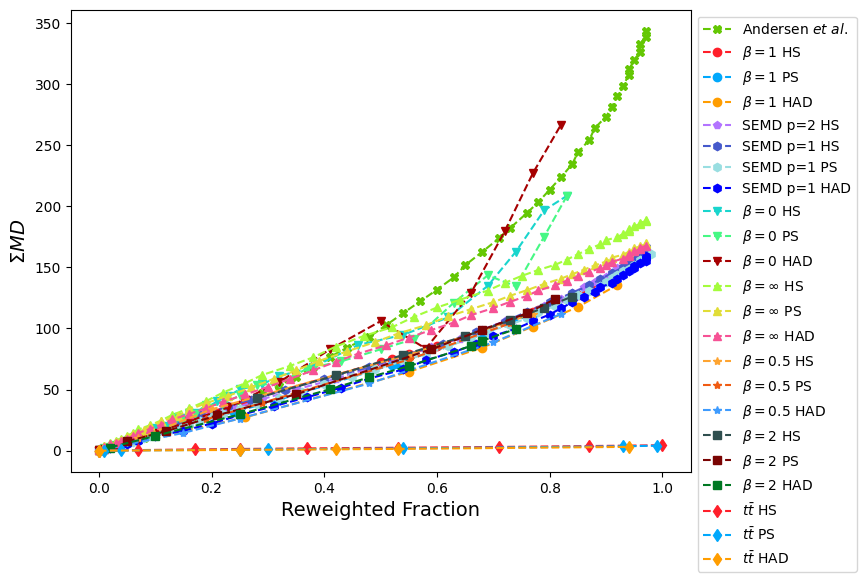

In [9]:
plt.figure(figsize=(8, 6))
ttbar_xs = 678.6208346399999
zjet_xs = 14685.82119

for key in dataFrames.keys():
    print(key)
    df = dataFrames[key]['df']
    plt.plot(df["fraction"], dataFrames[key]["xmd"], color = dataFrames[key]['color'], marker = dataFrames[key]['marker'], label = dataFrames[key]['title'], linestyle = '--')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 10)
    plt.xlabel('Reweighted Fraction', fontsize = 14)
    plt.ylabel(r'$\Sigma MD$', fontsize = 14);

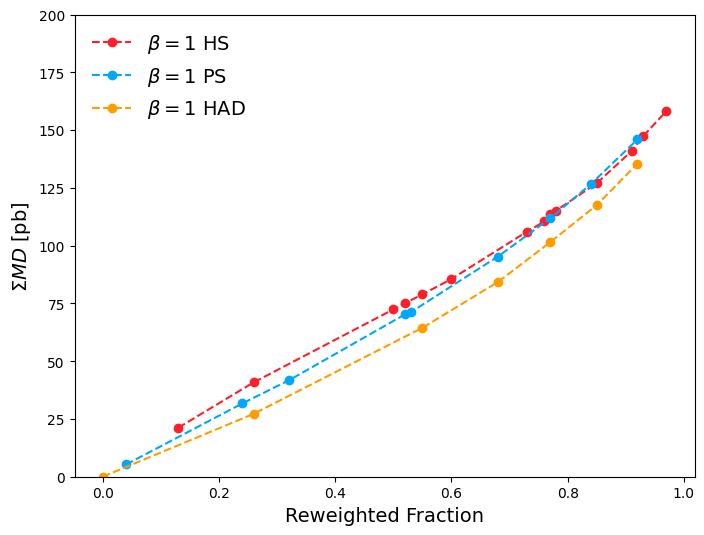

In [10]:
plt.figure(figsize=(8, 6))
datasets = [dataFrames["zjet_hp_df"], dataFrames["zjet_ps_df"], dataFrames["zjet_had_df"]]

for data in datasets:
    df = data['df']
    plt.plot(df["fraction"], data['xmd'], color = data['color'], marker = data['marker'], label = data['title'], linestyle = '--')

plt.legend(loc='best', fontsize = 14, frameon=False)
plt.xlabel('Reweighted Fraction', fontsize = 14)
plt.ylabel(r"$\Sigma MD$ [pb]", fontsize = 14)
plt.ylim([0,200]);
#plt.savefig('hp_xmd_updated.png', bbox_inches='tight')

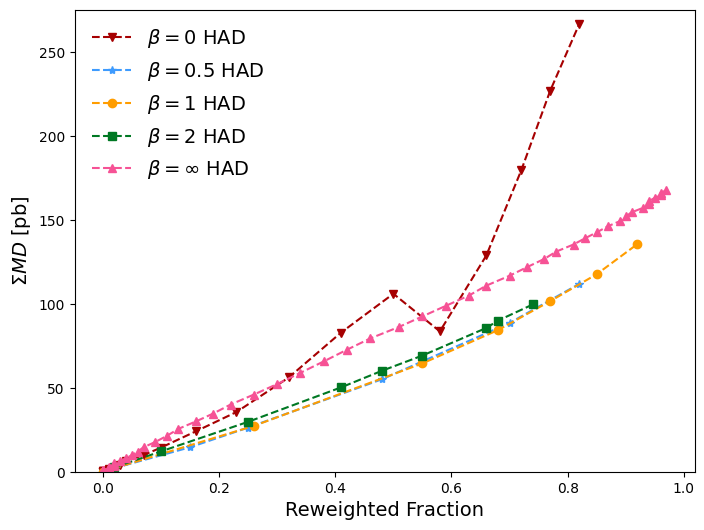

In [11]:
plt.figure(figsize=(8, 6))
datasets = [dataFrames["zjet_b0_had_df"], dataFrames["zjet_b0p5_had_df"], dataFrames["zjet_had_df"], dataFrames["zjet_b2_had_df"], dataFrames["zjet_binf_had_df"]]

for data in datasets:
    df = data['df']
    plt.plot(df["fraction"], data['xmd'], color = data['color'], marker = data['marker'], label = data['title'], linestyle = '--')

plt.legend(loc='best', fontsize = 14, frameon=False)
plt.xlabel('Reweighted Fraction', fontsize = 14)
plt.ylabel(r"$\Sigma MD$ [pb]", fontsize = 14)
plt.ylim([0,275]);
#plt.savefig('hp_xmd_updated.png', bbox_inches='tight')

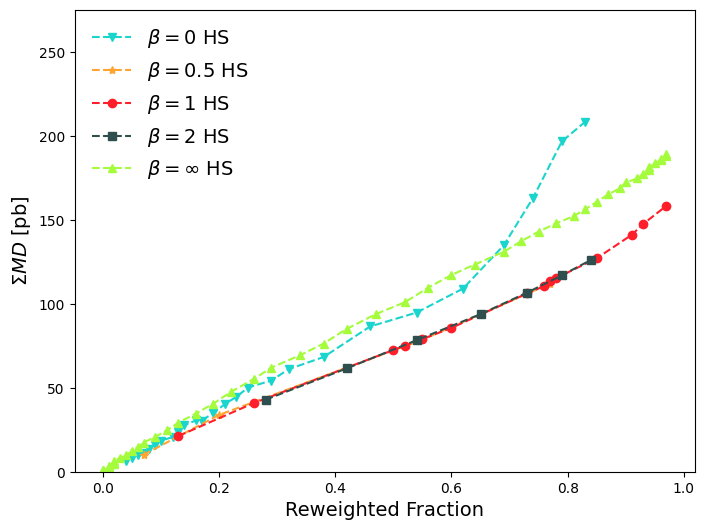

In [12]:
plt.figure(figsize=(8, 6))
datasets = [dataFrames["zjet_b0_hp_df"], dataFrames["zjet_b0p5_hp_df"], dataFrames["zjet_hp_df"], dataFrames["zjet_b2_hp_df"], dataFrames["zjet_binf_hp_df"]]

for data in datasets:
    df = data['df']
    plt.plot(df["fraction"], data['xmd'], color = data['color'], marker = data['marker'], label = data['title'], linestyle = '--')

plt.legend(loc='best', fontsize = 14, frameon=False)
plt.xlabel('Reweighted Fraction', fontsize = 14)
plt.ylabel(r"$\Sigma MD$ [pb]", fontsize = 14)
plt.ylim([0,275]);
#plt.savefig('hp_xmd_updated.png', bbox_inches='tight')

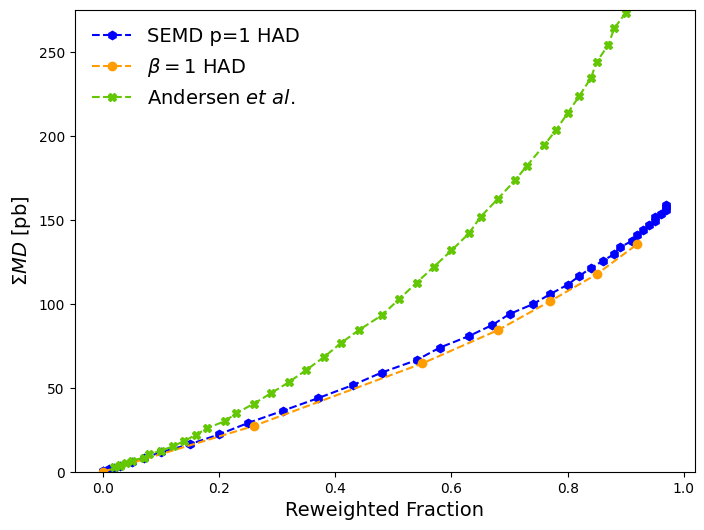

In [13]:
plt.figure(figsize=(8, 6))
datasets = [dataFrames["zjet_SEMD_had_df"], dataFrames["zjet_had_df"], dataFrames["zjet_jeppe_df"]]

for data in datasets:
    df = data['df']
    plt.plot(df["fraction"], data['xmd'], color = data['color'], marker = data['marker'], label = data['title'], linestyle = '--')

plt.legend(loc='best', fontsize = 14, frameon=False)
plt.xlabel('Reweighted Fraction', fontsize = 14)
plt.ylabel(r"$\Sigma MD$ [pb]", fontsize = 14)
plt.ylim([0,275]);
#plt.savefig('hp_xmd_updated.png', bbox_inches='tight')

(0.0, 1.02)

<Figure size 800x600 with 0 Axes>

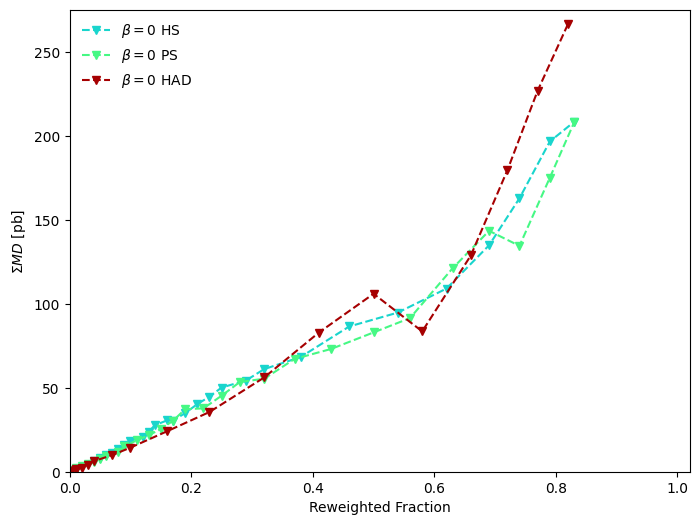

In [18]:
plt.figure(figsize=(8, 6))

plt.figure(figsize=(8, 6))
datasets = [dataFrames["zjet_b0_hp_df"], dataFrames["zjet_b0_ps_df"], dataFrames["zjet_b0_had_df"]]

for data in datasets:
    df = data['df']
    plt.plot(df["fraction"], data['xmd'], color = data['color'], marker = data['marker'], label = data['title'], linestyle = '--')

plt.legend(loc='best', frameon=False)
plt.xlabel('Reweighted Fraction')
plt.ylabel(r"$\Sigma MD$ [pb]")
plt.ylim([0,275]);
plt.xlim([0,1.02])

NameError: name 'hp_betainf_neg_percent' is not defined

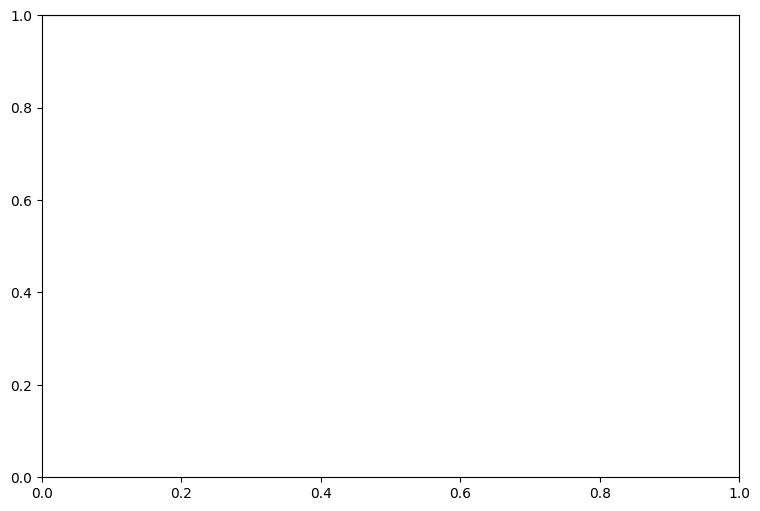

In [19]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(zjet_jeppe_df["radius"].values), zjet_jeppe_df["fraction"].values, color = 'maroon', marker = 'v', label = 'Andersen et al', linestyle = '--')
plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [ ]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(zjet_jeppe_df["radius"].values), zjet_jeppe_df["fraction"].values, color = 'maroon', marker = 'v', label = 'Andersen et al', linestyle = '--')
plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

NameError: name 'hp_beta0_neg_percent' is not defined

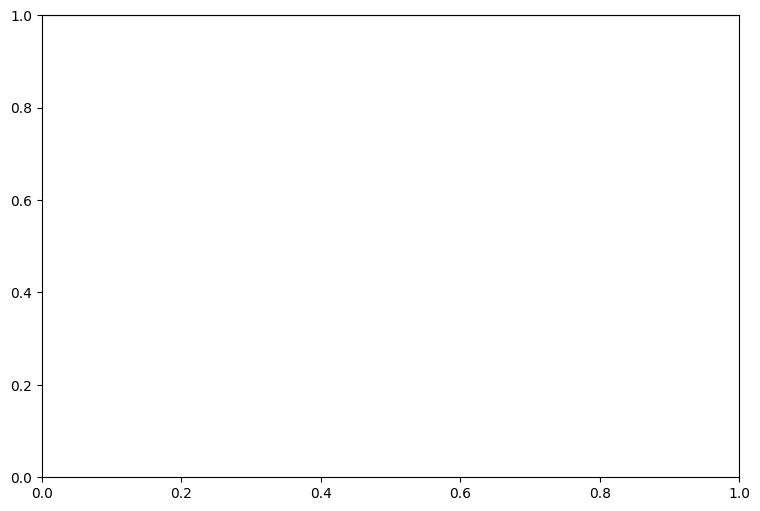

In [20]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [21]:
def x_at_nearest_y(radii, percent, target=0.5):
    """Return radius value whose percent is closest to target."""
    radii = np.asarray(radii, dtype=float)
    percent = np.asarray(percent, dtype=float)

    good = np.isfinite(radii) & np.isfinite(percent)
    radii = radii[good]
    percent = percent[good]

    idx = np.argmin(np.abs(percent - target))
    return radii[idx]
def plot_reweight_fractions_aligned(
    curves,
    target=0.5,
    align_to=0.0,
    normalize=False,
    figsize=(9, 6),
    save_name="reweight_frac_aligned.png",
    xlim=None
):
    """
    Plot many radius/percent curves on one figure, shifted so each curve's
    nearest point to `target` lands at x = `align_to`.

    curves should be a list of dictionaries:
        {
            "radii": radii_array,
            "percent": percent_array,
            "label": "Hard Process β = 1 EMD",
            "color": "red",
            "marker": "o",
            "linestyle": "--",
        }
    """

    fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(1, color="black", label="100% Reweighted")

    for curve in curves:
        radii = np.asarray(curve["radii"], dtype=float)
        percent = np.asarray(curve["percent"], dtype=float)


        x50 = x_at_nearest_y(radii, percent, target=target)
        if normalize:
            radii = radii / x50
            x50 = x_at_nearest_y(radii, percent, target=target)
            x_plot = radii + align_to
        else:
            x_plot = radii - x50 + align_to

        ax.plot(
            x_plot,
            percent,
            color=curve.get("color", None),
            marker=curve.get("marker", "o"),
            linestyle=curve.get("linestyle", "--"),
            label=curve.get("label", None),
        )

    ax.set_ylim([0, 1.05])
    if xlim!=None:
        print(xlim[0])
        ax.set_xlim(xlim[0], xlim[1])
    ax.set_xscale("log")
    ax.set_xlabel(rf"Radius [GeV]", fontsize=14)
    ax.set_ylabel("Reweighted Fraction", fontsize=14)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=12)

    fig.savefig(save_name, bbox_inches="tight")
    return fig, ax

In [22]:
curves = [
    # {"radii": betainf_radii, "percent": hp_betainf_neg_percent,  "color": "purple", "marker": "x", "label": "Hard Process β = ∞ EMD"},
    # {"radii": betainf_radii, "percent": sho_betainf_neg_percent, "color": "brown",  "marker": "x", "label": "Showered β = ∞ EMD"},
    # {"radii": betainf_radii, "percent": had_betainf_neg_percent, "color": "pink",   "marker": "x", "label": "Hadronization β = ∞ EMD"},

    {"radii": hp_beta2_radii,  "percent": hp_beta2_neg_percent,  "color": "mediumslateblue", "marker": "+", "label": "Hard Process β = 2 EMD"},
    {"radii": sho_beta2_radii, "percent": sho_beta2_neg_percent, "color": "plum",            "marker": "+", "label": "Showered β = 2 EMD"},
    {"radii": had_beta2_radii, "percent": had_beta2_neg_percent, "color": "midnightblue",    "marker": "+", "label": "Hadronization β = 2 EMD"},

    {"radii": hp_radii,  "percent": hp_neg_percent,  "color": "red",    "marker": "o", "label": "Hard Process β = 1 EMD"},
    {"radii": sho_radii, "percent": sho_neg_percent, "color": "blue",   "marker": "o", "label": "Showered β = 1 EMD"},
    {"radii": had_radii, "percent": had_neg_percent, "color": "orange", "marker": "o", "label": "Hadronization β = 1 EMD"},

    # {"radii": hp_beta0p5_radii,  "percent": hp_beta0p5_neg_percent,  "color": "green",       "marker": "s", "label": "Hard Process β = 0.5 EMD"},
    # {"radii": sho_beta0p5_radii, "percent": sho_beta0p5_neg_percent, "color": "magenta",     "marker": "s", "label": "Showered β = 0.5 EMD"},
    # {"radii": had_beta0p5_radii, "percent": had_beta0p5_neg_percent, "color": "lightsalmon", "marker": "s", "label": "Hadronization β = 0.5 EMD"},

    # {"radii": hp_semd_radii, "percent": hp_semd_neg_percent, "color": "cyan", "marker": "v", "label": "Hard Process p = 2 SEMD"},

    {"radii": beta0_radii, "percent": hp_beta0_neg_percent,  "color": "lime",            "marker": "*", "label": "Hard Process β = 0 EMD"},
    {"radii": beta0_radii, "percent": sho_beta0_neg_percent, "color": "mediumturquoise", "marker": "*", "label": "Showered β = 0 EMD"},
    {"radii": beta0_radii, "percent": had_beta0_neg_percent, "color": "mediumpurple",    "marker": "*", "label": "Hadronization β = 0 EMD"},

    # {"radii": hp_p1semd_radii,  "percent": hp_p1semd_neg_percent,  "color": "burlywood", "marker": "d", "label": "Hard Process p = 1 SEMD"},
    # {"radii": sho_p1semd_radii, "percent": sho_p1semd_neg_percent, "color": "olive",     "marker": "d", "label": "Showered p = 1 SEMD"},
    # {"radii": had_p1semd_radii, "percent": had_p1semd_neg_percent, "color": "turquoise", "marker": "d", "label": "Hadronization p = 1 SEMD"},
   {"radii":np.array(zjet_jeppe_df["radius"].values), "percent":zjet_jeppe_df["fraction"].values, "color":'maroon', "marker":'v', "label":'Anderson et al'}
]

NameError: name 'hp_beta2_radii' is not defined

In [23]:
fig, ax = plot_reweight_fractions_aligned(
    curves,
    target=0.5,
    align_to=0.0,
    normalize=True,
    save_name="reweight_frac_aligned_50percent.png",
    xlim=[0.4, 4]
)

NameError: name 'curves' is not defined

NameError: name 'hp_betainf_neg_percent' is not defined

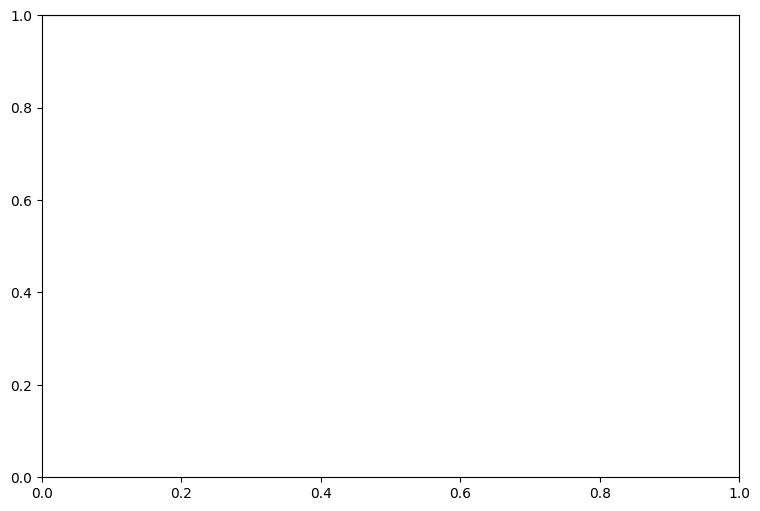

In [24]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_beta2_radii)*(1/np.mean(hp_beta2_radii))+10, hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii)*(1/np.mean(sho_beta2_radii))+10, sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii)*(1/np.mean(had_beta2_radii))+10, had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(hp_radii)*(1./np.mean(hp_radii))+20, hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii)*(1/np.mean(sho_radii))+20, sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii)*(1/np.mean(had_radii))+20, had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot((np.array(hp_beta0p5_radii)*(1/np.mean(hp_beta0p5_radii)))+30, hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot((np.array(sho_beta0p5_radii)*(1/np.mean(sho_beta0p5_radii)))+30, sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot((np.array(had_beta0p5_radii)*(1/np.mean(had_beta0p5_radii)))+30, had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')

plt.plot((np.array(hp_semd_radii)*(1/np.mean(hp_semd_radii)))*40, hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')


plt.plot(np.array(hp_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')


print(np.array(hp_semd_radii)*(70/np.max(hp_semd_radii)))
# plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

NameError: name 'hp_betainf_neg_percent' is not defined

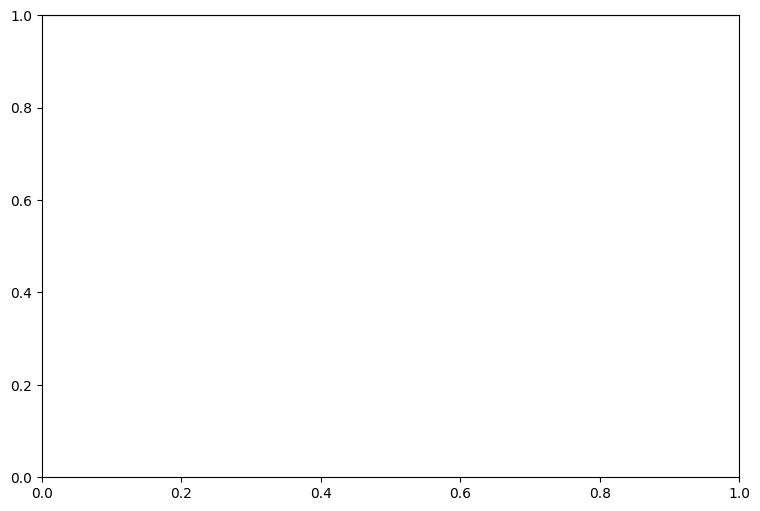

In [25]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ ', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞', linestyle = '--')

plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0', linestyle = '--')


plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')


print(np.array(hp_semd_radii)*(70/np.max(hp_semd_radii)))
# plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [ ]:
hp_means = [np.mean(i/14550) for i in hp_reweights]
hp2_means = [np.mean((i/14550)**2) for i in hp_reweights]
hp_var = [np.var(i/14550) for i in hp_reweights]

sho_means = [np.mean(i/14550) for i in sho_reweights]
sho2_means = [np.mean((i/14550)**2) for i in sho_reweights]
sho_var = [np.var(i/14550) for i in sho_reweights]

had_means = [np.mean(i/14550) for i in had_reweights]
had2_means = [np.mean((i/14550)**2) for i in had_reweights]
had_var = [np.var(i/14550) for i in had_reweights]

hp_beta0p5_means = [np.mean(i/14550) for i in hp_beta0p5_reweights]
hp2_beta0p5_means = [np.mean((i/14550)**2) for i in hp_beta0p5_reweights]
hp_beta0p5_var = [np.var(i/14550) for i in hp_beta0p5_reweights]

sho_beta0p5_means = [np.mean(i/14550) for i in sho_beta0p5_reweights]
sho2_beta0p5_means = [np.mean((i/14550)**2) for i in sho_beta0p5_reweights]
sho_beta0p5_var = [np.var(i/14550) for i in sho_beta0p5_reweights]

had_beta0p5_means = [np.mean(i/14550) for i in had_beta0p5_reweights]
had2_beta0p5_means = [np.mean((i/14550)**2) for i in had_beta0p5_reweights]
had_beta0p5_var = [np.var(i) for i in had_beta0p5_reweights]

hp_beta2_means = [np.mean(i) for i in hp_beta2_reweights]
hp2_beta2_means = [np.mean((i)**2) for i in hp_beta2_reweights]
hp_beta2_var = [np.var(i) for i in hp_beta2_reweights]

sho_beta2_means = [np.mean(i) for i in sho_beta2_reweights]
sho2_beta2_means = [np.mean((i)**2) for i in sho_beta2_reweights]
sho_beta2_var = [np.var(i) for i in sho_beta2_reweights]

had_beta2_means = [np.mean(i) for i in had_beta2_reweights]
had2_beta2_means = [np.mean((i)**2) for i in had_beta2_reweights]
had_beta2_var = [np.var(i) for i in had_beta2_reweights]

hp_beta0_means = [np.mean(i) for i in hp_beta0_reweights]
hp2_beta0_means = [np.mean(i**2) for i in hp_beta0_reweights]
hp_beta0_var = [np.var(i) for i in hp_beta0_reweights]

sho_beta0_means = [np.mean(i) for i in sho_beta0_reweights]
sho2_beta0_means = [np.mean(i**2) for i in sho_beta0_reweights]
sho_beta0_var = [np.var(i) for i in sho_beta0_reweights]

had_beta0_means = [np.mean(i) for i in had_beta0_reweights]
had2_beta0_means = [np.mean(i**2) for i in had_beta0_reweights]
had_beta0_var = [np.var(i) for i in had_beta0_reweights]

hp_betainf_means = [np.mean(i) for i in hp_betainf_reweights]
hp2_betainf_means = [np.mean(i**2) for i in hp_betainf_reweights]
hp_betainf_var = [np.var(i) for i in hp_betainf_reweights]

sho_betainf_means = [np.mean(i) for i in sho_betainf_reweights]
sho2_betainf_means = [np.mean(i**2) for i in sho_betainf_reweights]
sho_betainf_var = [np.var(i) for i in sho_betainf_reweights]

had_betainf_means = [np.mean(i) for i in had_betainf_reweights]
had2_betainf_means = [np.mean(i**2) for i in had_betainf_reweights]
had_betainf_var = [np.var(i) for i in had_betainf_reweights]

hp_p1semd_means = [np.mean(i) for i in hp_p1semd_reweights]
hp2_p1semd_means = [np.mean(i**2) for i in hp_p1semd_reweights]
hp_p1semd_var = [np.var(i) for i in hp_p1semd_reweights]

sho_p1semd_means = [np.mean(i) for i in sho_p1semd_reweights]
sho2_p1semd_means = [np.mean(i**2) for i in sho_p1semd_reweights]
sho_p1semd_var = [np.var(i) for i in sho_p1semd_reweights]

had_p1semd_means = [np.mean(i) for i in had_p1semd_reweights]
had2_p1semd_means = [np.mean(i**2) for i in had_p1semd_reweights]
had_p1semd_var = [np.var(i) for i in had_p1semd_reweights]

hp_semd_means = [np.mean(i) for i in hp_semd_reweights]
hp2_semd_means = [np.mean(i**2) for i in hp_semd_reweights]
hp_semd_var = [np.var(i) for i in hp_semd_reweights]

orig_mean = np.mean(weight)
orig2_mean = np.mean(weight**2)
orig_var = np.var(weight)

In [26]:
plt.plot(hp_neg_percent, hp_var / orig_var, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(sho_neg_percent, sho_var / orig_var, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(had_neg_percent, had_var / orig_var, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(hp_beta0p5_neg_percent, hp_beta0p5_var / orig_var, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(sho_beta0p5_neg_percent, sho_beta0p5_var / orig_var, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(had_beta0p5_neg_percent, had_beta0p5_var / orig_var, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')

plt.plot(hp_beta2_neg_percent, hp_beta2_var / orig_var, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(sho_beta2_neg_percent, sho_beta2_var / orig_var, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(had_beta2_neg_percent, had_beta2_var / orig_var, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(hp_beta0_neg_percent, hp_beta0_var / orig_var, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(sho_beta0_neg_percent, sho_beta0_var / orig_var, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(had_beta0_neg_percent, had_beta0_var / orig_var, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(hp_betainf_neg_percent, hp_betainf_var / orig_var, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(sho_betainf_neg_percent, sho_betainf_var / orig_var, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(had_betainf_neg_percent, had_betainf_var / orig_var, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(hp_p1semd_neg_percent, hp_p1semd_var / orig_var, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(sho_p1semd_neg_percent, sho_p1semd_var / orig_var, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(had_p1semd_neg_percent, had_p1semd_var / orig_var, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(hp_semd_neg_percent, hp_semd_var / orig_var, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.axhline(0, color = 'black', linestyle = '--', label = 'Fully positive, uniform sample')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Reweighted Fraction')
plt.ylabel('Variance of Weights wrt Original Variance')
plt.savefig('variance.png', bbox_inches='tight')

NameError: name 'hp_neg_percent' is not defined

In [27]:
# had_ML_radii = np.linspace(7,70,50)
# had_ML_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/ML_had_reweights.npy')

# had_ML_xmd_distances = []

# const = -min(weight)
# print(const)

# for i in range(50):
#     print('------------------------------------------------------------')
#     print(f'Now starting: max radius = {had_ML_radii[i]}')
#     print('------------------------------------------------------------')
#     had_ML_xmd_distances.append(xmd_distance(points, (had_ML_reweights[i]+const), (weight+const), pos_distmatrix = distmatrix))

# np.save('had_ML_XMD_jenmethod_constisminweight.npy', had_ML_xmd_distances)

NameError: name 'hp_neg_percent' is not defined

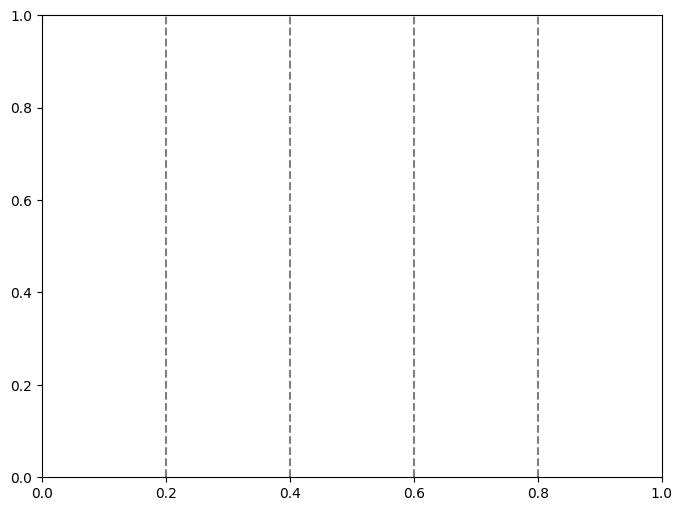

In [28]:
plt.figure(figsize=(8, 6))

plt.axvline(0.2, color = 'gray', linestyle = '--')
plt.axvline(0.4, color = 'gray', linestyle = '--')
plt.axvline(0.6, color = 'gray', linestyle = '--')
plt.axvline(0.8, color = 'gray', linestyle = '--')

plt.plot(hp_neg_percent, 1 / (np.array(hp_means)**2 / hp2_means), color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(sho_neg_percent, 1 / (np.array(sho_means)**2 / sho2_means), color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(had_neg_percent, 1 / (np.array(had_means)**2 / had2_means), color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(hp_beta0p5_neg_percent, 1 / (np.array(hp_beta0p5_means)**2 / hp2_beta0p5_means), color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(sho_beta0p5_neg_percent, 1 / (np.array(sho_beta0p5_means)**2 / sho2_beta0p5_means), color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(had_beta0p5_neg_percent, 1 / (np.array(had_beta0p5_means)**2 / had2_beta0p5_means), color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')

plt.plot(hp_beta2_neg_percent, 1 / (np.array(hp_beta2_means)**2 / hp2_beta2_means), color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(sho_beta2_neg_percent, 1 / (np.array(sho_beta2_means)**2 / sho2_beta2_means), color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(had_beta2_neg_percent, 1 / (np.array(had_beta2_means)**2 / had2_beta2_means), color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(hp_beta0_neg_percent, 1 / (np.array(hp_beta0_means)**2 / hp2_beta0_means), color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(sho_beta0_neg_percent, 1 / (np.array(sho_beta0_means)**2 / sho2_beta0_means), color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(had_beta0_neg_percent, 1 / (np.array(had_beta0_means)**2 / had2_beta0_means), color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(hp_betainf_neg_percent, 1 / (np.array(hp_betainf_means)**2 / hp2_betainf_means), color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(sho_betainf_neg_percent, 1 / (np.array(sho_betainf_means)**2 / sho2_betainf_means), color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(had_betainf_neg_percent, 1 / (np.array(had_betainf_means)**2 / had2_betainf_means), color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(hp_p1semd_neg_percent, 1 / (np.array(hp_p1semd_means)**2 / hp2_p1semd_means), color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(sho_p1semd_neg_percent, 1 / (np.array(sho_p1semd_means)**2 / sho2_p1semd_means), color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(had_p1semd_neg_percent, 1 / (np.array(had_p1semd_means)**2 / had2_p1semd_means), color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(hp_semd_neg_percent, 1 / (np.array(hp_semd_means)**2 / hp2_semd_means), color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.axhline(1, color = 'black', linestyle = '--', label = 'Fully positive, uniform sample')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlim([0,1])
plt.xlabel('Reweighted Fraction', fontsize = 14)
plt.ylabel('Statistical Dilution', fontsize = 14)
plt.savefig('dilution.png', bbox_inches='tight')

In [29]:
path = '/users/rrjain/XMD/tenK_XMD/trial1/'
had_reweights = [ np.load(f'{path}had_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}had_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_11GeV.npy'), np.load(f'{path}had_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_12GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_13GeV.npy'), np.load(f'{path}had_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_14GeV.npy'), np.load(f'{path}had_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_16GeV.npy'), np.load(f'{path}had_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_17GeV.npy'), np.load(f'{path}had_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}had_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_19GeV.npy'), np.load(f'{path}had_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}had_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}had_reweight_0to10k_25GeV.npy'), np.load(f'{path}had_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}had_reweight_0to10k_30GeV.npy'), np.load(f'{path}had_reweight_0to10k_150GeV.npy')]

sho_reweights = [np.load(f'{path}sho_reweight_0to10k_7p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_8GeV.npy'), np.load(f'{path}sho_reweight_0to10k_8p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_9GeV.npy'), np.load(f'{path}sho_reweight_0to10k_9p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}sho_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_11GeV.npy'), np.load(f'{path}sho_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_12GeV.npy'),
             np.load(f'{path}sho_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_13GeV.npy'), np.load(f'{path}sho_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_14GeV.npy'), np.load(f'{path}sho_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_16GeV.npy'), np.load(f'{path}sho_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_17GeV.npy'), np.load(f'{path}sho_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}sho_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_19GeV.npy'), np.load(f'{path}sho_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}sho_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}sho_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}sho_reweight_0to10k_25GeV.npy'), np.load(f'{path}sho_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}sho_reweight_0to10k_30GeV.npy'), np.load(f'{path}sho_reweight_0to10k_150GeV.npy')]

hp_reweights = [np.load(f'{path}hp_reweight_0to10k_5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_5p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_6GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_6p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_7GeV.npy'), np.load(f'{path}hp_reweight_0to10k_7p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_8GeV.npy'), np.load(f'{path}hp_reweight_0to10k_8p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_9GeV.npy'), np.load(f'{path}hp_reweight_0to10k_9p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_10GeV.npy'),
                np.load(f'{path}hp_reweight_0to10k_10p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_11GeV.npy'), np.load(f'{path}hp_reweight_0to10k_11p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_12GeV.npy'),
             np.load(f'{path}hp_reweight_0to10k_12p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_13GeV.npy'), np.load(f'{path}hp_reweight_0to10k_13p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_14GeV.npy'), np.load(f'{path}hp_reweight_0to10k_14p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_15GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_15p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_16GeV.npy'), np.load(f'{path}hp_reweight_0to10k_16p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_17GeV.npy'), np.load(f'{path}hp_reweight_0to10k_17p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_18GeV.npy'),
             np.load(f'{path}hp_reweight_0to10k_18p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_19GeV.npy'), np.load(f'{path}hp_reweight_0to10k_19p5GeV.npy'), 
                np.load(f'{path}hp_reweight_0to10k_20GeV.npy'), 
             np.load(f'{path}hp_reweight_0to10k_22p5GeV.npy'), np.load(f'{path}hp_reweight_0to10k_25GeV.npy'), np.load(f'{path}hp_reweight_0to10k_27p5GeV.npy'), 
             np.load(f'{path}hp_reweight_0to10k_30GeV.npy'), np.load(f'{path}hp_reweight_0to10k_150GeV.npy')]

hp_semd_radii = np.linspace(100,10000,50)
hp_semd_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/semd_reweights.npy')

infR_radii = np.logspace(-3,1,20)
hp_infR_reweights = np.load('infR_reweights_hp.npy')
sho_infR_reweights = np.load('infR_reweights_sho.npy')
had_infR_reweights = np.load('infR_reweights_had.npy')


rand_reweight = np.zeros((25,10000))
neg_num = np.linspace(len(weight[weight<0]),0,25, dtype = 'int')

def create_mixed_array(N, M):
    arr_pos = np.random.rand(N)        # N numbers in [0, 1]
    arr_neg = -np.random.rand(M)       # M numbers in [-1, 0]
    arr = np.concatenate([arr_pos, arr_neg])
    np.random.shuffle(arr)             # shuffle in-place
    return arr

random_distances = []
for i in range(25):
    rand_reweight[i] = create_mixed_array(10000-neg_num[i], neg_num[i])

rand_reweight = np.array(rand_reweight)


jeppe_radii = np.logspace(1.6,3,50)
jeppe_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/jeppe_reweights.npy')
hp_ML_radii = np.linspace(3,30,50)
hp_ML_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/ML_hp_reweights.npy')

sho_ML_radii = np.linspace(5,50,50)
sho_ML_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/ML_sho_reweights.npy')

had_ML_radii = np.linspace(7,70,50)
had_ML_reweights = np.load('/users/rrjain/XMD/tenK_XMD/trial1/ML_had_reweights.npy')

PermissionError: [Errno 13] Permission denied: '/users/rrjain/XMD/tenK_XMD/trial1/had_reweight_0to10k_10GeV.npy'

In [30]:
had_temp = []
for i in range(len(had_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    had_temp.append(1 - len(np.where(had_reweights[i] < 0)[0]) / num_negs)

sho_temp = []
for i in range(len(sho_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    sho_temp.append(1 - len(np.where(sho_reweights[i] < 0)[0]) / num_negs)

hp_temp = []
for i in range(len(hp_reweights)):
    num_negs = len(np.where(weight < 0)[0])
    hp_temp.append(1 - len(np.where(hp_reweights[i] < 0)[0]) / num_negs)

semd_temp = []
for i in range(50):
    num_negs = len(np.where(weight < 0)[0])
    semd_temp.append(1 - len(np.where(hp_semd_reweights[i] < 0)[0]) / num_negs)

hp_infR_temp = []
sho_infR_temp = []
had_infR_temp = []
for i in range(20):
    num_negs = len(np.where(weight<0)[0])
    hp_infR_temp.append(1 - len(np.where(hp_infR_reweights[i] < 0)[0]) / num_negs)
    sho_infR_temp.append(1 - len(np.where(sho_infR_reweights[i] < 0)[0]) / num_negs)
    had_infR_temp.append(1 - len(np.where(had_infR_reweights[i] < 0)[0]) / num_negs)

random_temp = []
for i in range(25):
    num_negs = len(np.where(weight<0)[0])
    random_temp.append(1-len(np.where(rand_reweight[i] < 0)[0]) / num_negs)

jeppe_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    jeppe_temp.append(1-len(np.where(jeppe_reweights[i] < 0)[0]) / num_negs)


hp_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    hp_ML_temp.append(1-len(np.where(hp_ML_reweights[i] < 0)[0]) / num_negs)


sho_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    sho_ML_temp.append(1-len(np.where(sho_ML_reweights[i] < 0)[0]) / num_negs)


had_ML_temp = []
for i in range(50):
    num_negs = len(np.where(weight<0)[0])
    had_ML_temp.append(1-len(np.where(had_ML_reweights[i] < 0)[0]) / num_negs)

NameError: name 'had_reweights' is not defined